In [2]:
import pandas as pd

<font size="5">Data Analysis</font>

In [ ]:
df = pd.read_csv('/yourpath/processed_amsterdam_airbnb_data.csv')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6168 entries, 0 to 6167
Data columns (total 48 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            6168 non-null   int64  
 1   last_scraped                                  6168 non-null   str    
 2   host_id                                       6168 non-null   int64  
 3   host_since                                    6168 non-null   str    
 4   host_response_time                            6168 non-null   str    
 5   host_is_superhost                             6168 non-null   str    
 6   host_listings_count                           6168 non-null   int64  
 7   host_total_listings_count                     6168 non-null   int64  
 8   host_identity_verified                        6168 non-null   str    
 9   neighbourhood_cleansed                        6168 non-null   str    
 10 

In [28]:
df_neighborhood = (
    df.groupby('neighbourhood_cleansed')
    .agg({"price":"mean"})
    .sort_values("price")
)
df_neighborhood.tail()

,price
neighbourhood_cleansed,
De Pijp - Rivierenbuurt,209.604730
Oud-Noord,215.015748
Zuid,216.789894
Centrum-West,234.994363
Centrum-Oost,238.921536


In [29]:
df_accomodates = (
    df.query("neighbourhood_cleansed == 'Centrum-Oost'")
    .groupby('accommodates')
    .agg({"price" : "mean"})
    .sort_values('price')
)
df_accomodates.head()

,price
accommodates,
1,91.307692
2,187.427711
3,229.818182
4,309.856383
5,333.200000


In [94]:
df_roomtype = (
    df.groupby('room_type')
    .agg({"price":"mean"})
    .sort_values("price")
)
df_roomtype.tail()

,price
room_type,
Shared room,148.781250
Private room,155.587500
Hotel room,198.203146
Entire home/apt,217.252901


In [38]:
df_over_time = (
    df.set_index("host_since")
    .resample("YE")
    .agg({
        "neighbourhood_cleansed" : "count",
        "price" : "mean"
    })
)
df_over_time.head()

,neighbourhood_cleansed,price
host_since,,
2008-12-31,2,89.000000
2009-12-31,4,230.000000
2010-12-31,43,172.930233
2011-12-31,178,184.028090
2012-12-31,599,198.437396


<font size="5">Visualisation</font>

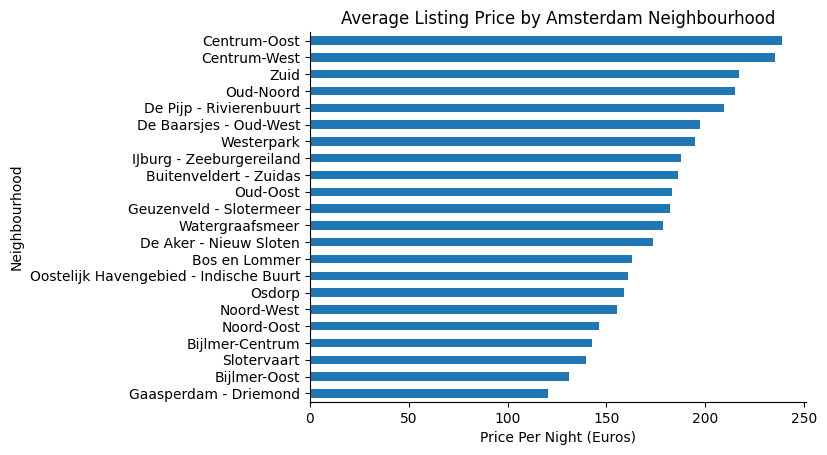

In [ ]:
import seaborn as sns

(df_neighborhood
.plot
.barh(
    title = "Average Listing Price by Amsterdam Neighbourhood",
    xlabel = "Price Per Night (Euros)",
    ylabel = "Neighbourhood",
    legend = None
)
)

sns.despine()

In [ ]:
# Creating a map visualisation for heatmap comprehension
import plotly.express as px
import json

with open("/Users/ayaansaeed/desktop/ClaudeCode/AirBnb Project/neighbourhoods.geojson") as f:
      geojson = json.load(f)

df_map = df.groupby('neighbourhood_cleansed')['price'].mean().reset_index()

fig = px.choropleth_map(
    df_map,
    geojson=geojson,
    locations='neighbourhood_cleansed',
    featureidkey='properties.neighbourhood',
    color='price',
    color_continuous_scale='YlOrRd',
    map_style='open-street-map',
    zoom=11,
    center={"lat": 52.3676, "lon": 4.9041},
    title='Average Airbnb Price by Neighbourhood',
    width=1000,
    height=700
)
fig.show()

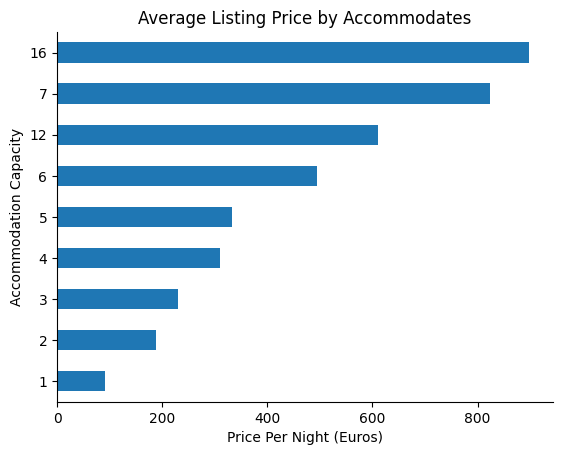

In [75]:
(df_accomodates
.plot
.barh(
    title = "Average Listing Price by Accommodates",
    xlabel = "Price Per Night (Euros)",
    ylabel = "Accommodation Capacity",
    legend = None
)
)

sns.despine()

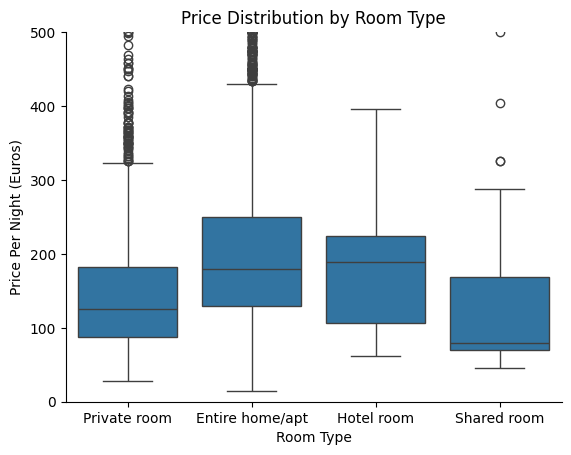

In [114]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots()
sns.boxplot(data=df, x='room_type', y='price', ax=ax)
ax.set_ylim(0, 500)
ax.set_title('Price Distribution by Room Type')
ax.set_xlabel('Room Type')
ax.set_ylabel('Price Per Night (Euros)')
sns.despine()
plt.show()

<font size="5">Time-Series Visualisations</font>

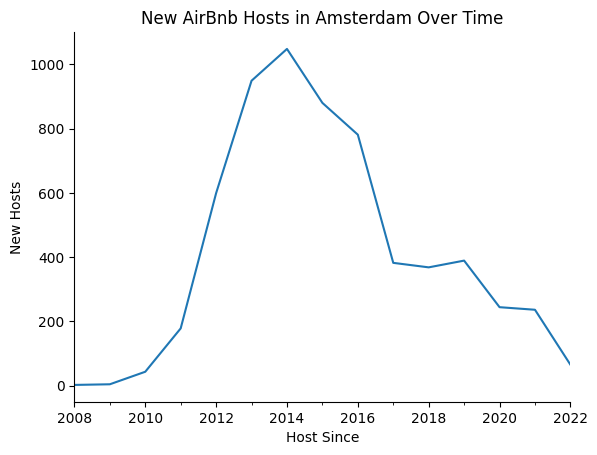

In [ ]:
df_over_time["neighbourhood_cleansed"].plot(
    ylabel="New Hosts",
    title="New AirBnb Hosts in Amsterdam Over Time",
    xlabel="Time"
)
sns.despine()

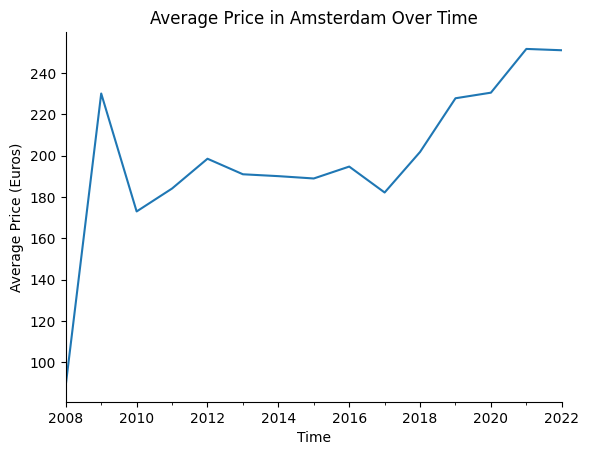

In [115]:
df_over_time["price"].plot(
    ylabel="Average Price (Euros)",
    title="Average Price in Amsterdam Over Time",
    xlabel="Time"
)
sns.despine()

Text(0.5, 1.0, 'Comparison of Price vs. Number of Hosts Over Time')

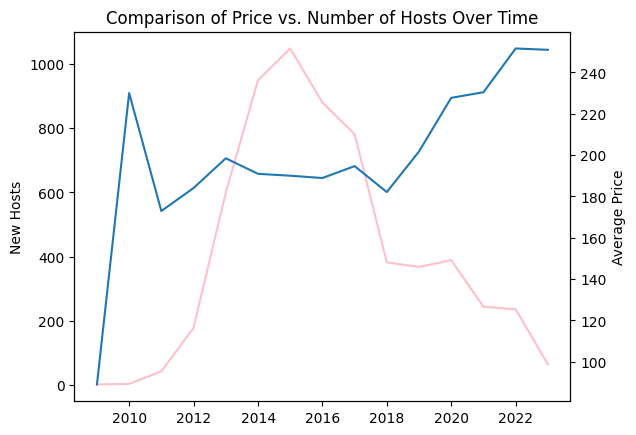

In [93]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

ax.plot(
    df_over_time.index,
    df_over_time['neighbourhood_cleansed'],
    label="New Hosts",
    c="pink"

)
ax.set_ylabel("New Hosts")

ax2 = ax.twinx()
ax2.plot(
    df_over_time.index,
    df_over_time['price'],
    label="Average Price",

)

ax2.set_ylabel("Average Price")

ax.set_title("Comparison of Price vs. Number of Hosts Over Time")